<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/20_note.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mixed Precision Training

參考：
- [Understanding Mixed Precision Training](https://medium.com/data-science/understanding-mixed-precision-training-4b246679c7c4)
- [Mixed Precision Training（Pytorch 範例程式）](https://fcuai.tw/2020/08/14/mixed-precision/)
- [PyTorch 源码解读之 torch.cuda.amp: 自动混合精度详解](https://zhuanlan.zhihu.com/p/348554267)

mixed precision training:

"Mixed precision training converts the weights to FP16 and calculates the gradients, before converting them back to FP32 before multiplying by the learning rate and updating the weights in the optimizer."

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*htZ4PF2fZ0ttJ5HdsIaAbQ.png" />

loss scaling:

"During loss scaling, the loss is scaled by a predefined factor after the forward pass to ensure it falls within the range of representable FP16 values. Due to the chain rule, this scales the gradients by the same factor, so the actual gradients can be retrieved after back-propagation."

<img src="https://miro.medium.com/v2/resize:fit:720/format:webp/1*re_VnoLEk-yXKtXuQuu2aA.png" width=900 />



[PyTorch Typical Mixed Precision Training](https://docs.pytorch.org/docs/stable/notes/amp_examples.html#typical-mixed-precision-training)

```python
# Creates model and optimizer in default precision
model = Net().cuda()
optimizer = optim.SGD(model.parameters(), ...)

# Creates a GradScaler once at the beginning of training.
scaler = GradScaler()

for epoch in epochs:
    for input, target in data:
        optimizer.zero_grad()

        # Runs the forward pass with autocasting.
        with autocast(device_type='cuda', dtype=torch.float16):
            output = model(input)
            loss = loss_fn(output, target)

        # Scales loss.  Calls backward() on scaled loss to create scaled gradients.
        # Backward passes under autocast are not recommended.
        # Backward ops run in the same dtype autocast chose for corresponding forward ops.
        scaler.scale(loss).backward()

        # scaler.step() first unscales the gradients of the optimizer's assigned params.
        # If these gradients do not contain infs or NaNs, optimizer.step() is then called,
        # otherwise, optimizer.step() is skipped.
        scaler.step(optimizer)

        # Updates the scale for next iteration.
        scaler.update()
```

## Neural Style Transfer

參考：
- [Creating Intricate Art with Neural Style Transfer](https://becominghuman.ai/creating-intricate-art-with-neural-style-transfer-e5fee5f89481)

<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*btAtU_VrgmKBbG1gakXV2w.png" />

## Neural Cellular Automata (NCA)

Neural Cellular Automata (NCA) are an extension of traditional cellular automata, using a neural network in place of the discrete update rules.

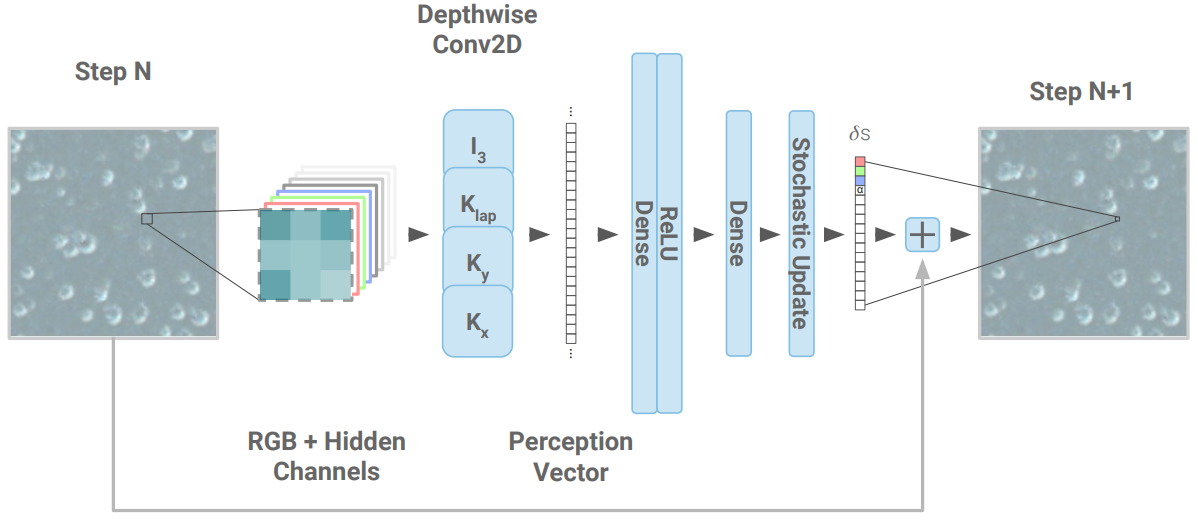

[explore NCA](https://neuralpatterns.io/)

GPT:

| NCA                  | MCMC                         |
| -------------------- | ---------------------------- |
| 起始於隨機狀態              | 起始於初始樣本                      |
| 使用局部規則演化（可以是隨機的）     | 使用轉移機率生成新樣本                  |
| 經過多步收斂到穩定狀態          | 經過多步收斂到 target 分布            |
| 無明確的 acceptance rule | 有接受/拒絕（如 MH）或條件機率更新（如 Gibbs） |


GPT:

| 特性         | Neural Cellular Automata (NCA) | Graph Neural Networks (GNN)  |
| ---------- | ------------------------------ | ---------------------------- |
| **結構拓撲**   | 固定的網格（如2D grid）                | 任意圖結構                        |
| **節點狀態**   | 每個 cell 有向量狀態                  | 每個節點有特徵向量                    |
| **鄰居感知**   | 鄰近 cell（如上下左右）                 | 鄰接節點（依圖拓撲）                   |
| **訊息傳遞機制** | CNN 或其他局部感知操作                  | 聚合鄰居資訊（如 mean/sum/attention） |
| **更新方式**   | 可學的局部規則（MLP, CNN）              | 可學的聚合與更新（GNN layer）          |
| **多步疊代**   | 多次演化，狀態收斂                      | 多層 message passing，嵌入收斂      |

| 概念                        | 解釋                                   |
| ------------------------- | ------------------------------------ |
| **局部資訊**                  | 每個單元（cell/node）只能看到鄰近資訊              |
| **局部運算器（local operator）** | MLP、CNN、GNN 層都是學習到的本地更新規則            |
| **全局演化（emergence）**       | 經過多次局部操作後，整體系統表現出有意義的全局結構（如圖像、分類、修復） |

## 影片的 colab

- [17_DDPM_v2.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/17_DDPM_v2.ipynb)
- [16A_StyleTransfer.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/16A_StyleTransfer.ipynb)
- [16B_NCA.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/16B_NCA.ipynb)